# 03_model_evaluation_optimization (versión corregida)

Notebook robustecido para evaluación comparativa, optimización de hiperparámetros y clustering con validaciones de nulos, pipelines consistentes y resúmenes finales seguros.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

POSSIBLE_PATHS = [
    Path('../data/03_primary/rrhh_encoded.csv'),
    Path('data/03_primary/rrhh_encoded.csv'),
    Path('/home/user/rrhh_encoded.csv')
]

RUTA = next((p for p in POSSIBLE_PATHS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError('No se encontró rrhh_encoded.csv en rutas esperadas.')

print('Archivo usado:', RUTA)


Archivo usado: ..\data\03_primary\rrhh_encoded.csv


In [2]:

df = pd.read_csv(RUTA, encoding='cp1252')
print('Shape original:', df.shape)
display(df.head())


Shape original: (286, 62)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,antiguedad_anios,total_ausencias,dias_ausencia_total,dias_ausencia_promedio,ausencias_injustificadas,tipo_ausencia_mas_frecuente,dias_ausencia_just_no,dias_ausencia_just_sã­,total_capacitaciones,horas_capacitacion_total,horas_capacitacion_promedio,nota_promedio_capacitacion,capacitaciones_completadas,cumple_min_capacitaciones,nota_estado_abandonado,nota_estado_completado,nota_estado_en_curso,nota_estado_inscrito,total_evaluaciones,puntaje_desempeno_promedio,competencias_tecnicas_promedio,competencias_blandas_promedio,puntaje_desempeno_max,puntaje_desempeno_min,tasa_ausentismo_pct,tasa_completitud_cap,score_desempeno,segmento_desempeno,riesgo_ausentismo,salario_norm,dias_ausencia_total_norm,horas_capacitacion_total_norm,puntaje_desempeno_promedio_norm,competencias_tecnicas_promedio_std,competencias_blandas_promedio_std,tipo_contrato_enc,jornada_enc,departamento_Finanzas,departamento_Legal,departamento_Logã?Stica,departamento_Logã­Stica,departamento_Marketing,departamento_Operaciones,departamento_Rrhh,departamento_Ti,departamento_Ventas,tipo_ausencia_mas_frecuente_Desconocido,tipo_ausencia_mas_frecuente_Falta Injustificada,tipo_ausencia_mas_frecuente_Licencia Maternal,tipo_ausencia_mas_frecuente_Licencia Mã?Dica,tipo_ausencia_mas_frecuente_Licencia Mã©Dica,tipo_ausencia_mas_frecuente_Permiso,tipo_ausencia_mas_frecuente_Vacaciones
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,11.4,1.0,17.0,17.00,1.0,Licencia Mã?Dica,17.0,0.0,1.0,40.0,40.0,5.70,1.0,1.0,0.0,5.7,0.0,0.0,1.0,4.20,1.7,5.80,4.2,4.2,6.8,100.0,3.77,Medio,Moderado,0.0995,0.0749,0.1370,0.6000,-0.8414,1.3004,1.0,0.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,2,Ignacio Nãºã±Ez Hernã¡Ndez,23306873-1,Logã­Stica,Analista,2015-01-12,4563559.0,Plazo Fijo,Completa,11.3,1.0,29.0,29.00,0.0,Permiso,0.0,29.0,2.0,64.0,32.0,2.65,1.0,1.0,3.2,2.1,0.0,0.0,1.0,6.30,3.9,1.30,6.3,6.3,11.6,50.0,4.58,Medio,Crítico,0.6300,0.1278,0.2192,0.9000,0.2454,-0.9899,2.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,3,Josã© Dã­Az Muã±Oz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,11.3,3.0,38.0,12.67,1.0,Licencia Maternal,20.0,18.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,3.0,3.43,5.2,4.67,4.8,1.3,15.2,0.0,4.21,Medio,Crítico,0.0574,0.1674,0.0000,0.4900,0.8876,0.7253,1.0,0.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,4,Felipe Castro Muã±Oz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Prã¡Ctica,Completa,11.3,1.0,21.0,21.00,1.0,Licencia Maternal,21.0,0.0,1.0,16.0,16.0,6.50,0.0,0.0,0.0,0.0,6.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,8.4,0.0,0.00,Bajo,Moderado,0.5738,0.0925,0.0548,0.0000,-1.6811,-1.6516,3.0,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,5,Carolina Zambrano Dã­Az,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,11.2,1.0,27.0,27.00,0.0,Licencia Mã©Dica,0.0,27.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1.0,6.00,1.7,3.10,6.0,6.0,10.8,0.0,4.13,Medio,Crítico,0.1052,0.1189,0.0000,0.8571,-0.8414,-0.0738,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [3]:

# ---------- Preparación robusta ----------
df = df.copy()
df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols_all] = df[num_cols_all].replace([np.inf, -np.inf], np.nan)

possible_clf = ['segmento_desempeno', 'segmentodesempeno']
possible_reg = ['score_desempeno', 'scoredesempeno']
possible_drop = ['riesgo_ausentismo', 'riesgoausentismo']

target_clf = next((c for c in possible_clf if c in df.columns), None)
if target_clf is None:
    raise KeyError(f'No se encontró target de clasificación. Buscados: {possible_clf}')

# Filtrar filas con target válido
df = df[df[target_clf].notna()].copy()

remove_cols = [c for c in [target_clf] + possible_reg + possible_drop if c in df.columns]
X = df.drop(columns=remove_cols, errors='ignore').copy()
X = X.select_dtypes(include=[np.number]).copy()
y = df[target_clf].copy()

all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print('Columnas 100% nulas eliminadas:', all_nan_cols)
    X = X.drop(columns=all_nan_cols)

constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    print('Columnas constantes eliminadas:', constant_cols)
    X = X.drop(columns=constant_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Shape X total:', X.shape)
print('Train/Test:', X_train.shape, X_test.shape)
print('Distribución target:')
print(y.value_counts(dropna=False))
print('Nulos top 15:')
print(X.isna().sum().sort_values(ascending=False).head(15))


Shape X total: (286, 51)
Train/Test: (228, 51) (58, 51)
Distribución target:
segmento_desempeno
Medio    161
Bajo     115
Alto      10
Name: count, dtype: int64
Nulos top 15:
dias_ausencia_just_sã­            97
dias_ausencia_just_no             97
dias_ausencia_promedio            93
nota_estado_inscrito              79
nota_estado_completado            79
nota_promedio_capacitacion        79
nota_estado_en_curso              79
nota_estado_abandonado            79
horas_capacitacion_promedio       79
competencias_tecnicas_promedio    51
puntaje_desempeno_promedio        51
puntaje_desempeno_max             51
competencias_blandas_promedio     51
puntaje_desempeno_min             51
antiguedad_anios                   9
dtype: int64


## GridSearchCV y RandomizedSearchCV


In [4]:

# ---------- Optimización de hiperparámetros ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    error_score='raise'
)

grid.fit(X_train, y_train)
print('GridSearch best_score:', grid.best_score_)
print('GridSearch best_params:', grid.best_params_)

gb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_param_dist = {
    'model__n_estimators': [50, 100, 150, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_samples_split': [2, 5, 10]
}

rnd = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    error_score='raise'
)

rnd.fit(X_train, y_train)
print('RandomizedSearch best_score:', rnd.best_score_)
print('RandomizedSearch best_params:', rnd.best_params_)


GridSearch best_score: 0.8774632504982035
GridSearch best_params: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 50}
RandomizedSearch best_score: 0.8719685212637488
RandomizedSearch best_params: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__max_depth': 3, 'model__learning_rate': 0.05}


In [5]:

# ---------- Evaluación comparativa de modelos optimizados ----------
modelos_opt = pd.DataFrame([
    {
        'modelo': 'RF_Optimizado',
        'f1_weighted': f1_score(y_test, grid.best_estimator_.predict(X_test), average='weighted', zero_division=0)
    },
    {
        'modelo': 'GBM_Optimizado',
        'f1_weighted': f1_score(y_test, rnd.best_estimator_.predict(X_test), average='weighted', zero_division=0)
    }
]).sort_values('f1_weighted', ascending=False)

display(modelos_opt)


,modelo,f1_weighted
1,GBM_Optimizado,0.980014
0,RF_Optimizado,0.914980


## Clustering con KMeans y PCA


In [6]:

# ---------- Clustering con KMeans y PCA ----------
# Para clustering, se imputa antes de escalar
imputer_cluster = SimpleImputer(strategy='median')
X_cluster = imputer_cluster.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

resultados_codo = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    fila = {
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels)
    }
    resultados_codo.append(fila)

codo = pd.DataFrame(resultados_codo)
display(codo)


,k,inertia,silhouette
0,2,13469.752942,0.077367
1,3,12795.702960,0.067328
2,4,12385.509120,0.058652
3,5,11995.504419,0.063976
4,6,11721.847210,0.051520
5,7,11415.709510,0.045494
6,8,11210.577871,0.046388


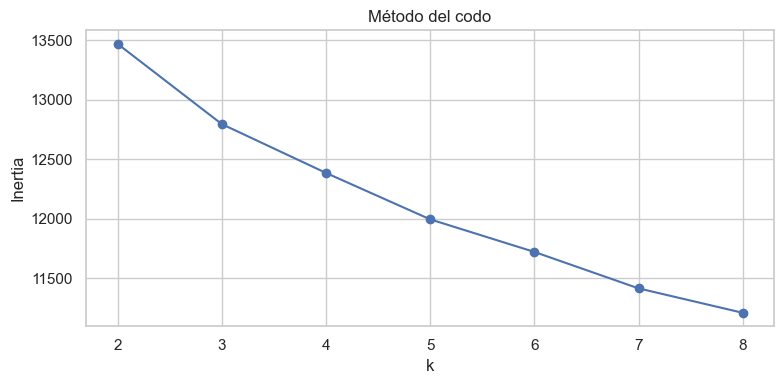

In [7]:

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(codo['k'], codo['inertia'], marker='o', label='Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Método del codo')
plt.tight_layout()
plt.show()


In [8]:

best_k = int(codo.sort_values('silhouette', ascending=False).iloc[0]['k'])
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1],
    'cluster': clusters.astype(str)
})

display(plot_df.head())


,pc1,pc2,cluster
0,0.543545,1.707412,1
1,1.027420,0.996960,1
2,2.437774,-2.317370,0
3,0.689717,-1.515379,0
4,0.728179,-2.514979,0


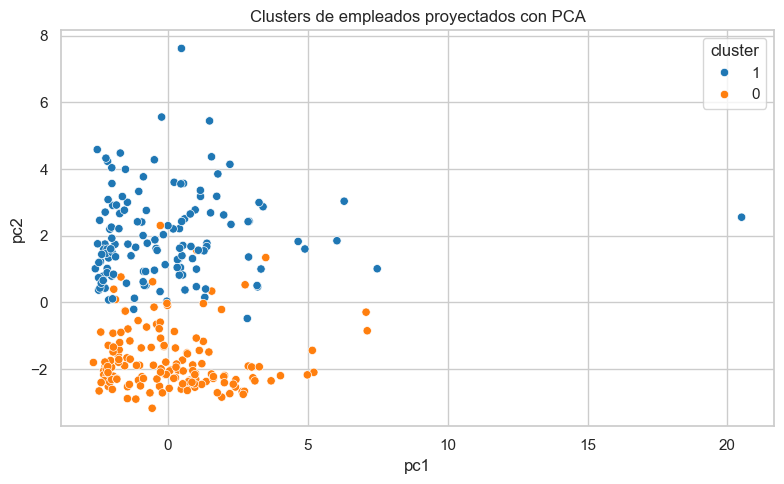

In [9]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='cluster', palette='tab10')
plt.title('Clusters de empleados proyectados con PCA')
plt.tight_layout()
plt.show()


## Análisis final


In [10]:

# ---------- Resumen final ----------
resumen = {
    'mejor_modelo_clasificacion_optimizado': modelos_opt.sort_values('f1_weighted', ascending=False).iloc[0]['modelo'],
    'mejor_f1': modelos_opt['f1_weighted'].max(),
    'mejor_k_silhouette': int(codo.sort_values('silhouette', ascending=False).iloc[0]['k']),
    'mejor_silhouette': codo['silhouette'].max(),
    'varianza_pca_2d': float(pca.explained_variance_ratio_.sum())
}

display(pd.Series(resumen))



mejor_modelo_clasificacion_optimizado    GBM_Optimizado
mejor_f1                                       0.980014
mejor_k_silhouette                                    2
mejor_silhouette                               0.077367
varianza_pca_2d                                0.198748
dtype: object